# Raymarcher Visualiser Experimentation Log
This notebook will be used to record the results of minor experiments performed using our raymarching visualiser.

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Experiment 1: Octree Acceleration
### Background
An octree is a tree data structure, with every internal node having eight children (octants). 3D space is divided into these octants, which allows for more efficient computation when used alongside raymarching algorithms. When 'marching', the ray first checks whether it intersects with the bounding boxes of these octree nodes. If a node is missed, all of its primitives (and subnodes), efficiently deleting a significant component of the search space.
### Experiment
Having octree acceleration implemented in our visualiser, we will measure the:
* Average Signed Distance Function (SDF) calls to render,
* Maximum SDFs to render and
* Minimum SDFs to render
grids of spheres, ranging in size from 1x1 (a single sphere), to a 'dense' 5x5 grid. Our aim is to measure and assess the impact of octree acceleration on computational efficiency. Both Sphere Tracing will be used as the underlying raymarcher algorithm, for feasible efficiency purposes (fixed step becomes too laggy when experimenting). 
### Results

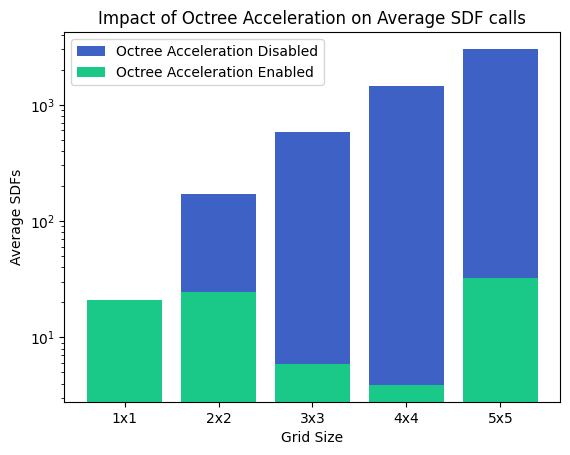

In [31]:
fig, ax = plt.subplots()

grids = ["1x1", "2x2", "3x3", "4x4", "5x5"]
octree_disabled = [21.02, 169.61, 582.68, 1436.94, 3010.41]
disabled_label = "Octree Acceleration Disabled"
disabled_colour = "#3e61c6"

octree_enabled = [21.02, 24.36, 5.87, 3.90, 32.06]
enabled_label = "Octree Acceleration Enabled" 
enabled_colour = "#1ac988"

ax.bar(grids, octree_disabled, label=disabled_label, color=disabled_colour)
ax.bar(grids, octree_enabled, label=enabled_label, color=enabled_colour)
plt.yscale("log")
ax.set_ylabel("Average SDFs")
ax.set_xlabel("Grid Size")
ax.set_title("Impact of Octree Acceleration on Average SDF calls")
ax.legend()

plt.savefig("octree_results/avg_sdfs.svg")

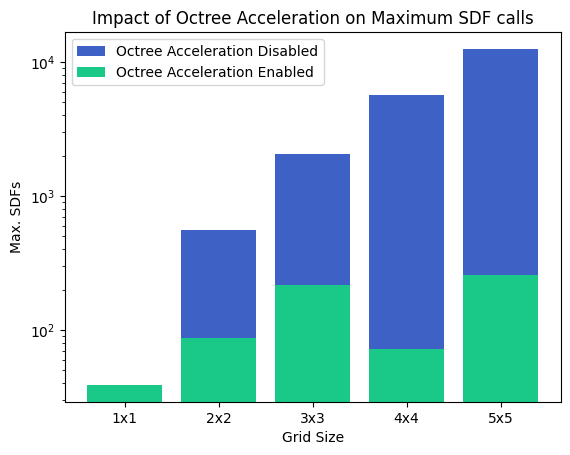

In [32]:
fig, ax = plt.subplots()

grids = ["1x1", "2x2", "3x3", "4x4", "5x5"]
octree_disabled = [39, 560, 2052, 5632, 12500]
disabled_label = "Octree Acceleration Disabled"
disabled_colour = "#3e61c6"

octree_enabled = [39, 88, 217, 72, 256]
enabled_label = "Octree Acceleration Enabled" 
enabled_colour = "#1ac988"

ax.bar(grids, octree_disabled, label=disabled_label, color=disabled_colour)
ax.bar(grids, octree_enabled, label=enabled_label, color=enabled_colour)
plt.yscale("log")
ax.set_ylabel("Max. SDFs")
ax.set_xlabel("Grid Size")
ax.set_title("Impact of Octree Acceleration on Maximum SDF calls")
ax.legend()

plt.savefig("octree_results/max_sdfs.svg")

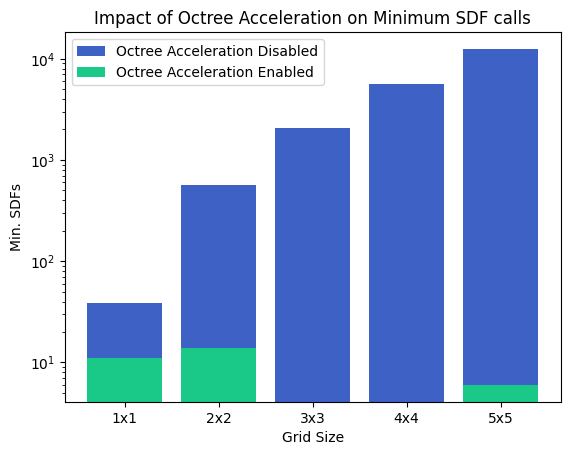

In [33]:
fig, ax = plt.subplots()

grids = ["1x1", "2x2", "3x3", "4x4", "5x5"]
octree_disabled = [39, 560, 2052, 5632, 12500]
disabled_label = "Octree Acceleration Disabled"
disabled_colour = "#3e61c6"

octree_enabled = [11, 14, 0, 0, 6]
enabled_label = "Octree Acceleration Enabled" 
enabled_colour = "#1ac988"

ax.bar(grids, octree_disabled, label=disabled_label, color=disabled_colour)
ax.bar(grids, octree_enabled, label=enabled_label, color=enabled_colour)
plt.yscale("log")
ax.set_ylabel("Min. SDFs")
ax.set_xlabel("Grid Size")
ax.set_title("Impact of Octree Acceleration on Minimum SDF calls")
ax.legend()

plt.savefig("octree_results/min_sdfs.svg")

Text(1.55, 10.3, '(1.55, 10.14)\nOptimal')

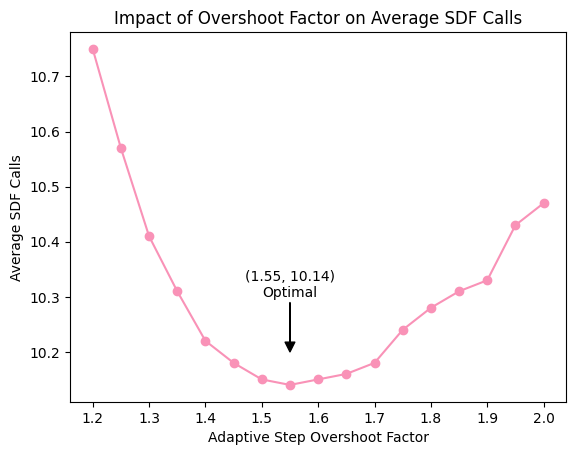

In [ ]:
fig, ax = plt.subplots()

x = [1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55,
     1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0]
y = [10.75, 10.57, 10.41, 10.31, 10.22, 10.18, 10.15, 10.14,
    10.15, 10.16, 10.18, 10.24, 10.28, 10.31, 10.33, 10.43, 10.47]
color = "#f992b7"

ax.plot(x, y, marker='o', color=color)
ax.set_xlabel("Adaptive Step Overshoot Factor")
ax.set_ylabel("Average SDF Calls")
ax.set_title("Impact of Overshoot Factor on Average SDF Calls")
plt.annotate('(1.55, 10.14)\nOptimal', xy=(1.55, 10.16), xytext=(1.55, 10.3),
             arrowprops=dict(facecolor='black', width=0.05, headwidth=7, headlength=7),
             ha='center')
